# Inverse Reinforcement Learning for Execution

**Execution environment**: local `uv run` on CPU.

IRL inverts the RL problem: instead of "given reward, find optimal policy,"
it asks "given expert behavior, what reward explains it?" This notebook
implements behavior cloning (direct imitation) and compares two reward-inference
methods on the same demonstrations: feature-expectation matching and sampled
Maximum Entropy IRL.

**Scope note**: This is a compact pedagogical implementation, not a
production-grade IRL system. A fixed, reproducible bank of sampled trajectories
approximates the MaxEnt partition function over the continuous environment,
while the feature-matching baseline uses fresh noisy-greedy rollouts. Both
produce illustrative linear weights rather than uniquely identified structural
rewards. Section 21.7 discusses exact dynamic-programming and adversarial
alternatives.

**Learning Outcomes**:
- Understand the difference between behavior cloning and reward inference
- Implement sampled MaxEnt IRL with a linear reward parameterization
- Compare trajectory likelihood with feature-expectation matching
- Interpret learned reward weights in a financial context
- Recognize the limitations of linear IRL in continuous action spaces

**Book Reference**: Chapter 21, Section 21.7.

**Prerequisites**: `optimal_execution_ppo` and `environments`.

In [1]:
"""Inverse Reinforcement Learning for Execution - infer reward functions from expert execution behavior."""

# Core imports
import warnings

import numpy as np
import polars as pl
from IPython.display import Markdown, display
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings("ignore", category=DeprecationWarning)


# Visualization
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Shared environment and calibration
from rl_calibration import CryptoMarketCalibrator
from rl_environments import ExecutionEnv

import utils  # noqa: F401
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
OUTPUT_DIR = get_output_dir(21, "inverse_rl")

In [3]:
TOTAL_SHARES = 5_000
EXECUTION_HORIZON = 30
N_EXPERT_TRAJECTORIES = 200
BC_EPOCHS = 500
IRL_ITERATIONS = 100
N_CANDIDATE_TRAJECTORIES = 400
MAXENT_L2 = 0.05
FEATURE_MATCH_ITERATIONS = 50
N_FEATURE_MATCH_TRAJECTORIES = 50
SEED = 42  # base seed; downstream rng instances seeded from this
EXPORT_RESULTS = False

In [4]:
set_global_seeds(SEED)

In [5]:
# Configuration
config = {
    "total_shares": TOTAL_SHARES,
    "execution_horizon": EXECUTION_HORIZON,
    "n_expert_trajectories": N_EXPERT_TRAJECTORIES,
    "bc_epochs": BC_EPOCHS,
    "irl_iterations": IRL_ITERATIONS,
    "n_candidate_trajectories": N_CANDIDATE_TRAJECTORIES,
    "maxent_l2": MAXENT_L2,
    "feature_match_iterations": FEATURE_MATCH_ITERATIONS,
    "n_feature_match_trajectories": N_FEATURE_MATCH_TRAJECTORIES,
}

print(f"Configuration: {config}")

Configuration: {'total_shares': 5000, 'execution_horizon': 30, 'n_expert_trajectories': 200, 'bc_epochs': 500, 'irl_iterations': 100, 'n_candidate_trajectories': 400, 'maxent_l2': 0.05, 'feature_match_iterations': 50, 'n_feature_match_trajectories': 50}


## 1. Generate Expert Demonstrations

We use TWAP (Time-Weighted Average Price) as our "expert" policy. TWAP is
deterministic and well-understood, making it ideal for demonstrating IRL.

The key question IRL answers: **What objective is TWAP optimizing?**
- Spoiler: TWAP minimizes timing risk by spreading execution uniformly
- It does NOT explicitly minimize market impact
- IRL should recover this implicit objective from observations

In [6]:
# Calibrate environment from real data
print("Calibrating simulation from real crypto data...")
calibrator = CryptoMarketCalibrator("BTCUSDT")
cal_params = calibrator.get_execution_env_params()

# Create environment
env = ExecutionEnv(
    total_shares=config["total_shares"],
    horizon=config["execution_horizon"],
    initial_price=100.0,
    cal_params=cal_params,
)

Calibrating simulation from real crypto data...


### Expert Policy (TWAP)

Our "expert" targets one equal schedule slice at each step. The environment
exposes actions as normalized pace controls, so the policy converts its target
share count through the environment API rather than treating the action as an
inventory fraction.

In [7]:
def twap_policy(obs: np.ndarray, env: ExecutionEnv) -> float:
    """Return the normalized pace action for the environment's TWAP slice."""
    if obs[0] <= 0:
        return 0.0
    target_shares = env.reference_trade_size()
    return float(env.target_shares_to_action(target_shares)[0])

### Collect Expert Demonstrations

Run the TWAP expert for multiple episodes, collecting state-action pairs
as training data for both behavior cloning and IRL.

In [8]:
def collect_expert_trajectories(
    env: ExecutionEnv,
    policy_fn,
    n_trajectories: int,
    seed: int = 42,
) -> dict:
    rng = np.random.default_rng(seed)

    states = []
    actions = []
    trajectories = []

    for _ in range(n_trajectories):
        obs, _ = env.reset(seed=int(rng.integers(0, 10000)))
        done = False
        traj_states = []
        traj_actions = []

        while not done:
            action = policy_fn(obs, env)
            traj_states.append(obs.copy())
            traj_actions.append(action)

            obs, _, terminated, truncated, _ = env.step(np.array([action]))
            done = terminated or truncated

        states.extend(traj_states)
        actions.extend(traj_actions)
        trajectories.append(
            {
                "states": np.array(traj_states),
                "actions": np.array(traj_actions),
                "total_shortfall": env.total_cost,
            }
        )

    return {
        "states": np.array(states),
        "actions": np.array(actions),
        "trajectories": trajectories,
    }

In [9]:
print(f"\nCollecting {config['n_expert_trajectories']} expert (TWAP) trajectories...")
expert_data = collect_expert_trajectories(
    env, twap_policy, n_trajectories=config["n_expert_trajectories"]
)

print(f"Total state-action pairs: {len(expert_data['states'])}")
print(f"State shape: {expert_data['states'].shape}")
print(f"Action range: [{expert_data['actions'].min():.3f}, {expert_data['actions'].max():.3f}]")

# Compute expert performance statistics
shortfalls = [t["total_shortfall"] for t in expert_data["trajectories"]]
print("\nExpert (TWAP) Performance:")
print(f"  Mean shortfall: {np.mean(shortfalls):.2f}")
print(f"  Std shortfall: {np.std(shortfalls):.2f}")
print(
    f"  Mean shortfall (bps): {np.mean(shortfalls) / (100 * config['total_shares']) * 10_000:.1f}"
)

Total state-action pairs: 6000
State shape: (6000, 6)
Action range: [0.500, 1.000]

Expert (TWAP) Performance:
  Mean shortfall: 2811.52
  Std shortfall: 9783.94
  Mean shortfall (bps): 56.2


## 2. Behavior Cloning

**Behavior cloning** is the simplest form of imitation learning: treat
demonstration data as supervised learning. Map states directly to actions.

**Advantages**:
- Simple to implement (standard regression)
- Fast to train
- Works well with abundant demonstrations

**Limitations**:
- No reward recovery (can't explain WHY the expert acts)
- Distribution shift: errors compound when policy visits new states
- Cannot improve upon the expert

In [10]:
# Split whole trajectories so adjacent states from one episode cannot appear
# on both sides of the behavior-cloning boundary.
trajectory_split = int(0.8 * len(expert_data["trajectories"]))
train_trajectories = expert_data["trajectories"][:trajectory_split]
test_trajectories = expert_data["trajectories"][trajectory_split:]
X_train = np.concatenate([traj["states"] for traj in train_trajectories])
y_train = np.concatenate([traj["actions"] for traj in train_trajectories])
X_test = np.concatenate([traj["states"] for traj in test_trajectories])
y_test = np.concatenate([traj["actions"] for traj in test_trajectories])

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 4800
Test samples: 1200


In [11]:
# Train behavior cloning models (simple and neural network)
print("\nTraining behavior cloning models...")

# Simple linear model
bc_linear = Ridge(alpha=0.1)
bc_linear.fit(X_train, y_train)

# Neural network
bc_nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=config["bc_epochs"],
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
)
bc_nn.fit(X_train, y_train)

# Evaluate
linear_train_mse = np.mean((bc_linear.predict(X_train) - y_train) ** 2)
linear_test_mse = np.mean((bc_linear.predict(X_test) - y_test) ** 2)
nn_train_mse = np.mean((bc_nn.predict(X_train) - y_train) ** 2)
nn_test_mse = np.mean((bc_nn.predict(X_test) - y_test) ** 2)

print("\nBehavior Cloning Results:")
print(f"  Linear - Train MSE: {linear_train_mse:.6f}, Test MSE: {linear_test_mse:.6f}")
print(f"  NN     - Train MSE: {nn_train_mse:.6f}, Test MSE: {nn_test_mse:.6f}")


Training behavior cloning models...



Behavior Cloning Results:
  Linear - Train MSE: 0.007269, Test MSE: 0.007273
  NN     - Train MSE: 0.000002, Test MSE: 0.000002


### Evaluate Cloned Policies

Run the learned policies in the execution environment to compare
their actual shortfall against the expert's.

In [12]:
def evaluate_policy(action_fn, env, episode_seeds: list[int]) -> dict:
    """Evaluate an action function on a fixed list of common episode seeds."""
    shortfalls = []
    action_histories = []

    for episode_seed in episode_seeds:
        obs, _ = env.reset(seed=episode_seed)
        done = False
        actions = []

        while not done:
            action = float(np.clip(action_fn(obs), 0, 1))
            actions.append(action)
            obs, reward, terminated, truncated, info = env.step(np.array([action]))
            done = terminated or truncated

        shortfalls.append(env.total_cost)
        action_histories.append(actions)

    return {
        "mean_shortfall": np.mean(shortfalls),
        "std_shortfall": np.std(shortfalls),
        "shortfalls": shortfalls,
        "action_histories": action_histories,
    }


# Evaluate BC policies
print("\nEvaluating behavior cloning policies...")
evaluation_seeds = list(range(20_000, 20_020))
expert_results = evaluate_policy(lambda obs: twap_policy(obs, env), env, evaluation_seeds)
bc_linear_results = evaluate_policy(
    lambda obs: bc_linear.predict(obs.reshape(1, -1))[0], env, evaluation_seeds
)
bc_nn_results = evaluate_policy(
    lambda obs: bc_nn.predict(obs.reshape(1, -1))[0], env, evaluation_seeds
)
expert_mean = expert_results["mean_shortfall"]

print("\nExecution Performance (mean shortfall):")
print(f"  Expert (TWAP):   {expert_mean:.2f}")
print(f"  BC Linear:       {bc_linear_results['mean_shortfall']:.2f}")
print(f"  BC Neural Net:   {bc_nn_results['mean_shortfall']:.2f}")


Evaluating behavior cloning policies...

Execution Performance (mean shortfall):
  Expert (TWAP):   5291.87
  BC Linear:       5289.66
  BC Neural Net:   5291.94


## 3. Maximum Entropy IRL

**Maximum Entropy IRL** goes beyond behavior cloning by assigning a
likelihood to complete trajectories under a linear reward:

- Assume reward is a linear function of features: $R(s,a) = \mathbf{w}^\top \boldsymbol{\phi}(s,a)$
- Score each trajectory by its cumulative reward
- Normalize scores with a partition function
- Maximize the likelihood of the expert demonstrations

For a fixed trajectory support $\mathcal{T}$,
$P(\tau\mid\mathbf{w})=\exp(\mathbf{w}^{\top}\Phi(\tau))/Z(\mathbf{w})$,
where $Z(\mathbf{w})=\sum_{\tau'\in\mathcal{T}}
\exp(\mathbf{w}^{\top}\Phi(\tau'))$. The log-likelihood gradient is the
expert feature count minus its expectation under this distribution.

**Financial Interpretation**:
- Features φ might include: spread, depth, inventory, time pressure
- Learned weights w reveal which factors the expert cares about
- Positive weight = expert seeks to maximize that feature
- Negative weight = expert seeks to minimize that feature

In [13]:
def extract_features(state: np.ndarray, action: float) -> np.ndarray:
    """
    Extract features for linear reward parameterization.

    Features designed to capture execution concerns:
    - inventory_remaining: penalize holding inventory
    - time_pressure: urgency near deadline
    - spread_cost: cost of trading at current spread
    - depth_quality: benefit of trading when liquidity is high
    - action_pace: normalized pace around the reference schedule
    - action_inventory_interaction: trade more when inventory is high

    State: [inventory_ratio, time_ratio, spread, depth, volatility, regime]
    """
    inventory = state[0]
    time_remaining = state[1]
    spread = state[2]
    depth = state[3]
    volatility = state[4]
    regime = state[5]

    # Time pressure increases as deadline approaches
    time_pressure = 1.0 - time_remaining

    return np.array(
        [
            # Core execution features
            inventory,  # 0: remaining inventory (want to reduce)
            time_pressure * inventory,  # 1: urgency-inventory interaction
            spread * action,  # 2: spread cost of trading
            depth * action,  # 3: benefit of trading in deep markets
            action,  # 4: normalized schedule pace
            # Risk features
            volatility * inventory,  # 5: volatility exposure
            regime * inventory,  # 6: stress regime risk
            # Interaction
            action * inventory,  # 7: trade more when inventory high
        ]
    )

### Feature Expectations

Compute the empirical mean of features across all expert trajectories for a
readable baseline. MaxEnt fitting below uses cumulative trajectory feature
counts because the likelihood is defined over complete paths.

In [14]:
def compute_feature_expectations(trajectories: list, extract_fn) -> np.ndarray:
    """Compute empirical feature expectations from trajectories."""
    feature_sums = None
    n_samples = 0

    for traj in trajectories:
        states = traj["states"]
        actions = traj["actions"]

        for state, action in zip(states, actions, strict=False):
            features = extract_fn(state, action)
            if feature_sums is None:
                feature_sums = np.zeros_like(features)
            feature_sums += features
            n_samples += 1

    return feature_sums / n_samples


# Compute expert feature expectations
expert_features = compute_feature_expectations(expert_data["trajectories"], extract_features)
print("Expert Feature Expectations:")
feature_names = [
    "inventory",
    "time_pressure*inv",
    "spread*action",
    "depth*action",
    "action",
    "vol*inventory",
    "regime*inventory",
    "action*inventory",
]
for name, val in zip(feature_names, expert_features, strict=False):
    print(f"  {name:20s}: {val:.4f}")

Expert Feature Expectations:
  inventory           : 0.5164
  time_pressure*inv   : 0.1664
  spread*action       : 0.3163
  depth*action        : 4.5224
  action              : 0.5167
  vol*inventory       : 0.3424
  regime*inventory    : 0.0386
  action*inventory    : 0.2587


### Fixed Trajectory Support

Exact MaxEnt IRL sums over every feasible trajectory. That is intractable in
this continuous environment, so the teaching implementation constructs one
fixed candidate bank before fitting. The bank combines expert paths with
seeded noisy-TWAP, front-loaded, back-loaded, liquidity-sensitive, and random
proposals. Keeping this support fixed is essential: it makes the sampled
partition function and likelihood deterministic.

In [15]:
def proposal_action(obs: np.ndarray, env: ExecutionEnv, kind: int, rng) -> float:
    """Draw an action from one of five weight-independent proposal policies."""
    twap = twap_policy(obs, env)
    if kind == 0:
        action = twap + 0.08 * rng.standard_normal()
    elif kind == 1:
        action = 0.8 + 0.06 * rng.standard_normal()
    elif kind == 2:
        action = (0.2 if obs[1] > 0.4 else 0.8) + 0.06 * rng.standard_normal()
    elif kind == 3:
        action = 0.25 + 0.5 * np.clip(obs[3], 0.0, 1.0)
    else:
        action = rng.beta(2.0, 2.0)
    return float(np.clip(action, 0.0, 1.0))

In [16]:
def sample_candidate_trajectory(env: ExecutionEnv, rng) -> dict:
    """Roll out one trajectory from a randomly chosen proposal policy."""
    kind = int(rng.integers(0, 5))
    obs, _ = env.reset(seed=int(rng.integers(0, 10000)))
    done = False
    traj_states, traj_actions = [], []
    while not done:
        action = proposal_action(obs, env, kind, rng)
        traj_states.append(obs.copy())
        traj_actions.append(action)
        obs, _, terminated, truncated, _ = env.step(np.array([action]))
        done = terminated or truncated
    return {"states": np.array(traj_states), "actions": np.array(traj_actions)}

Each row below is the cumulative feature vector $\Phi(\tau)$ for one complete
trajectory. The candidate bank is generated once and never depends on the
reward weights being estimated.

In [17]:
def trajectory_feature_counts(trajectories: list, extract_features_fn) -> np.ndarray:
    """Return one cumulative feature-count vector per trajectory."""
    return np.vstack(
        [
            np.sum(
                [
                    extract_features_fn(state, action)
                    for state, action in zip(traj["states"], traj["actions"], strict=False)
                ],
                axis=0,
            )
            for traj in trajectories
        ]
    )

The proposal trajectories augment, rather than replace, the training
demonstrations. Including both gives the partition approximation support near
the expert and across deliberately different execution schedules.

In [18]:
def build_candidate_bank(
    expert_trajectories: list,
    env: ExecutionEnv,
    n_candidates: int,
    seed: int,
) -> list:
    """Combine expert paths with a fixed bank of proposal trajectories."""
    rng = np.random.default_rng(seed)
    proposals = [sample_candidate_trajectory(env, rng) for _ in range(n_candidates)]
    return [*expert_trajectories, *proposals]

### MaxEnt Likelihood Optimization

On the fixed support, the partition function is an ordinary stable
log-sum-exp. Gradient ascent therefore optimizes a genuine trajectory
likelihood rather than relabeling a noisy greedy feature-matching loop.

In [19]:
def maxent_distribution(
    candidate_features: np.ndarray,
    weights: np.ndarray,
) -> tuple[np.ndarray, float]:
    """Return stable MaxEnt probabilities and the log-partition value."""
    logits = candidate_features @ weights
    max_logit = logits.max()
    exponentials = np.exp(logits - max_logit)
    return exponentials / exponentials.sum(), float(max_logit + np.log(exponentials.sum()))

Standardizing each trajectory-level feature controls conditioning without
changing the fixed candidate support or the likelihood being optimized.

In [20]:
def prepare_maxent_problem(
    expert_trajectories: list,
    candidate_trajectories: list,
    extract_features_fn,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Standardize trajectory feature counts for MaxEnt optimization."""
    expert_counts = trajectory_feature_counts(expert_trajectories, extract_features_fn)
    candidate_counts = trajectory_feature_counts(candidate_trajectories, extract_features_fn)
    candidate_std = candidate_counts.std(axis=0)
    feature_scale = np.where(candidate_std > 1e-8, candidate_std, 1.0)
    expert_target = (expert_counts / feature_scale).mean(axis=0)
    return expert_counts, candidate_counts / feature_scale, expert_target, feature_scale

The regularized objective combines the expert reward, log-partition term, and
the disclosed L2 penalty used during optimization.

In [21]:
def regularized_log_likelihood(
    expert_target: np.ndarray,
    candidate_features: np.ndarray,
    weights: np.ndarray,
    l2_penalty: float,
) -> float:
    """Evaluate the mean sampled MaxEnt objective."""
    _, log_partition = maxent_distribution(candidate_features, weights)
    likelihood = expert_target @ weights - log_partition
    return float(likelihood - 0.5 * l2_penalty * np.dot(weights, weights))

The optimizer standardizes feature counts for conditioning, applies the exact
finite-support likelihood gradient, and maps coefficients back to the original
feature units for interpretation.

In [22]:
def maxent_irl(
    expert_trajectories: list,
    candidate_trajectories: list,
    extract_features_fn,
    n_iterations: int = 100,
    learning_rate: float = 0.05,
    l2_penalty: float = 0.05,
) -> dict:
    """Fit a linear MaxEnt reward on a fixed sampled trajectory support."""
    problem = prepare_maxent_problem(
        expert_trajectories, candidate_trajectories, extract_features_fn
    )
    expert_counts, candidate_scaled, expert_target, feature_scale = problem
    scaled_weights = np.zeros(expert_target.shape[0])
    history = {"weights": [scaled_weights.copy()], "gradient_norm": [], "log_likelihood": []}

    print(f"Running sampled MaxEnt IRL on {len(candidate_trajectories)} fixed trajectories...")
    for iteration in range(n_iterations):
        probabilities, _ = maxent_distribution(candidate_scaled, scaled_weights)
        model_expectation = probabilities @ candidate_scaled
        gradient = expert_target - model_expectation - l2_penalty * scaled_weights
        step = learning_rate / np.sqrt(1.0 + iteration / 10.0)
        scaled_weights = scaled_weights + step * gradient

        mean_log_likelihood = regularized_log_likelihood(
            expert_target, candidate_scaled, scaled_weights, l2_penalty
        )
        history["weights"].append(scaled_weights.copy())
        history["gradient_norm"].append(np.linalg.norm(gradient))
        history["log_likelihood"].append(float(mean_log_likelihood))
        if (iteration + 1) % 10 == 0 or iteration == 0:
            print(f"  Iteration {iteration + 1:3d}: log likelihood = {mean_log_likelihood:.4f}")

    return {
        "weights": scaled_weights / feature_scale,
        "history": history,
        "expert_features": expert_counts.mean(axis=0),
        "candidate_count": len(candidate_trajectories),
        "feature_scale": feature_scale,
    }

In [23]:
# Fit reward weights using training trajectories only and a fixed candidate bank.
candidate_trajectories = build_candidate_bank(
    expert_trajectories=train_trajectories,
    env=env,
    n_candidates=config["n_candidate_trajectories"],
    seed=SEED + 10_000,
)
irl_result = maxent_irl(
    expert_trajectories=train_trajectories,
    candidate_trajectories=candidate_trajectories,
    extract_features_fn=extract_features,
    n_iterations=config["irl_iterations"],
    learning_rate=0.05,
    l2_penalty=config["maxent_l2"],
)

Running sampled MaxEnt IRL on 560 fixed trajectories...
  Iteration   1: log likelihood = -6.2966
  Iteration  10: log likelihood = -6.2391
  Iteration  20: log likelihood = -6.2239
  Iteration  30: log likelihood = -6.2140
  Iteration  40: log likelihood = -6.2064
  Iteration  50: log likelihood = -6.2002
  Iteration  60: log likelihood = -6.1950
  Iteration  70: log likelihood = -6.1905
  Iteration  80: log likelihood = -6.1866
  Iteration  90: log likelihood = -6.1831
  Iteration 100: log likelihood = -6.1799


### Feature-Expectation Matching Baseline

The comparison method uses the same update direction,
$\mu_E-\mu_{\pi_k}$, but estimates the policy expectation from fresh
noisy-greedy rollouts under the current weights. It has no partition
function and no trajectory-likelihood objective, so it is feature-expectation
matching rather than MaxEnt IRL.

In [24]:
def best_greedy_action(obs: np.ndarray, weights: np.ndarray, extract_features_fn) -> float:
    """Action in [0.01, 1.0] that maximizes the current linear reward."""
    action_grid = np.linspace(0.01, 1.0, 20)
    rewards = [np.dot(weights, extract_features_fn(obs, action)) for action in action_grid]
    return float(action_grid[int(np.argmax(rewards))])

Fresh rollouts depend on the current reward weights. That distinguishes this
iterative policy-matching procedure from the fixed MaxEnt support above.

In [25]:
def sample_feature_matching_trajectory(
    env: ExecutionEnv,
    weights: np.ndarray,
    extract_features_fn,
    rng,
) -> dict:
    """Roll out one episode under a noisy greedy policy."""
    obs, _ = env.reset(seed=int(rng.integers(0, 10000)))
    done = False
    traj_states, traj_actions = [], []
    while not done:
        greedy = best_greedy_action(obs, weights, extract_features_fn)
        action = float(np.clip(greedy + 0.1 * rng.standard_normal(), 0.01, 1.0))
        traj_states.append(obs.copy())
        traj_actions.append(action)
        obs, _, terminated, truncated, _ = env.step(np.array([action]))
        done = terminated or truncated
    return {"states": np.array(traj_states), "actions": np.array(traj_actions)}

The baseline records its residual feature mismatch so its stopping behavior
can be compared with MaxEnt likelihood optimization.

In [26]:
def feature_expectation_irl(
    expert_trajectories: list,
    env: ExecutionEnv,
    extract_features_fn,
    n_iterations: int = 50,
    learning_rate: float = 0.2,
    n_sample_trajectories: int = 50,
    seed: int = 42,
) -> dict:
    """Match expert feature expectations with noisy-greedy policy rollouts."""
    rng = np.random.default_rng(seed)
    expert_features = compute_feature_expectations(expert_trajectories, extract_features_fn)
    weights = np.zeros(len(expert_features))
    history = {"weights": [weights.copy()], "gradient_norm": []}

    print("Running feature-expectation matching...")
    for iteration in range(n_iterations):
        sampled = [
            sample_feature_matching_trajectory(env, weights, extract_features_fn, rng)
            for _ in range(n_sample_trajectories)
        ]
        policy_features = compute_feature_expectations(sampled, extract_features_fn)
        gradient = expert_features - policy_features
        weights = weights + learning_rate * gradient
        history["weights"].append(weights.copy())
        history["gradient_norm"].append(float(np.linalg.norm(gradient)))
        if (iteration + 1) % 10 == 0 or iteration == 0:
            print(
                f"  Iteration {iteration + 1:3d}: "
                f"feature mismatch = {history['gradient_norm'][-1]:.4f}"
            )

    return {"weights": weights, "history": history, "expert_features": expert_features}

In [27]:
feature_match_result = feature_expectation_irl(
    expert_trajectories=train_trajectories,
    env=env,
    extract_features_fn=extract_features,
    n_iterations=config["feature_match_iterations"],
    learning_rate=0.2,
    n_sample_trajectories=config["n_feature_match_trajectories"],
    seed=SEED + 20_000,
)

Running feature-expectation matching...
  Iteration   1: feature mismatch = 4.0759


  Iteration  10: feature mismatch = 4.0899


  Iteration  20: feature mismatch = 4.0599


  Iteration  30: feature mismatch = 4.0654


  Iteration  40: feature mismatch = 4.0770


  Iteration  50: feature mismatch = 4.0529


## 4. Compare Learned Reward Weights

Both methods use the same linear features and training demonstrations. Their
different objectives need not recover the same coefficients, especially when
correlated features make the reward non-identifiable.

In [28]:
maxent_weights = irl_result["weights"]
feature_match_weights = feature_match_result["weights"]
maxent_sorted = sorted(
    zip(feature_names, maxent_weights, strict=False), key=lambda x: abs(x[1]), reverse=True
)
feature_match_sorted = sorted(
    zip(feature_names, feature_match_weights, strict=False),
    key=lambda x: abs(x[1]),
    reverse=True,
)
weights_table = pl.DataFrame(
    {
        "feature": feature_names,
        "sampled_maxent": [round(float(weight), 4) for weight in maxent_weights],
        "feature_matching": [round(float(weight), 4) for weight in feature_match_weights],
    }
)
weights_table

feature,sampled_maxent,feature_matching
str,f64,f64
"""inventory""",-0.0887,-0.2639
"""time_pressure*inv""",0.0466,-0.1921
"""spread*action""",-0.0537,-0.0459
"""depth*action""",-0.0036,0.1685
"""action""",-0.092,0.1868
"""vol*inventory""",-0.0189,-0.1813
"""regime*inventory""",0.0109,-0.2592
"""action*inventory""",0.0562,0.4083


These weights are illustrative, **not uniquely identified** structural
estimates of trader preferences. MaxEnt raises demonstration likelihood within
a finite candidate bank; feature matching reduces a rollout-based moment gap.
A large coefficient in either method indicates association with expert
behavior, not necessarily a feature the deterministic TWAP rule uses.

In [29]:
# Visualize reward weight evolution
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Sampled MaxEnt Log Likelihood", "Reward Weights by Method"),
)

# Likelihood plot
fig.add_trace(
    go.Scatter(
        y=irl_result["history"]["log_likelihood"],
        mode="lines",
        name="Mean Log Likelihood",
        line=dict(color=COLORS["blue"]),
    ),
    row=1,
    col=1,
)

_ = fig.add_trace(
    go.Bar(
        x=feature_names,
        y=maxent_weights,
        marker_color=COLORS["blue"],
        name="Sampled MaxEnt",
    ),
    row=1,
    col=2,
)
_ = fig.add_trace(
    go.Bar(
        x=feature_names,
        y=feature_match_weights,
        marker_color=COLORS["amber"],
        name="Feature Matching",
    ),
    row=1,
    col=2,
)

The shared layout places the MaxEnt likelihood beside a coefficient comparison.
The bottom margin keeps rotated feature labels clear of the x-axis title.

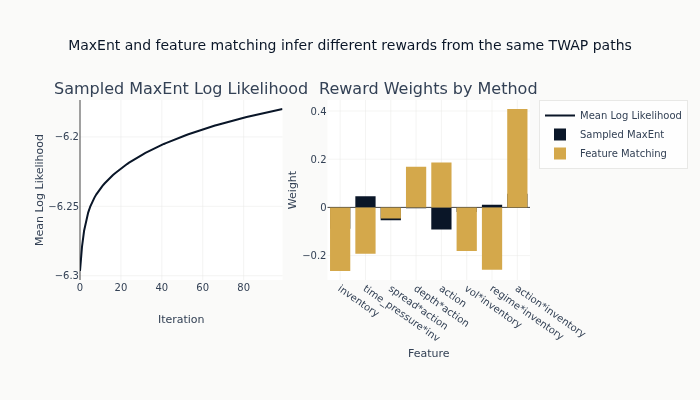

In [30]:
fig.update_layout(
    title="MaxEnt and feature matching infer different rewards from the same TWAP paths",
    showlegend=True,
    height=400,
    barmode="overlay",
    margin=dict(b=120),
)
fig.update_xaxes(title_text="Iteration", row=1, col=1)
fig.update_xaxes(title_text="Feature", tickangle=35, row=1, col=2)
fig.update_yaxes(title_text="Mean Log Likelihood", row=1, col=1)
fig.update_yaxes(title_text="Weight", row=1, col=2)

fig.show()

In [31]:
if EXPORT_RESULTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    weights_df = pl.DataFrame(
        {
            "feature": list(feature_names),
            "sampled_maxent": list(maxent_weights),
            "feature_matching": list(feature_match_weights),
        }
    )
    weights_df.write_parquet(OUTPUT_DIR / "irl_weights.parquet")
    diagnostics_df = pl.DataFrame(
        {
            "iteration": list(range(1, len(irl_result["history"]["log_likelihood"]) + 1)),
            "log_likelihood": irl_result["history"]["log_likelihood"],
            "gradient_norm": list(irl_result["history"]["gradient_norm"]),
        }
    )
    diagnostics_df.write_parquet(OUTPUT_DIR / "maxent_diagnostics.parquet")
    print(f"IRL weights and likelihood diagnostics saved to {OUTPUT_DIR}")

## 5. Compare Policies Under the Inferred Rewards

Rather than solving another full dynamic program, MaxEnt uses a one-step
Boltzmann diagnostic policy while feature matching uses its noisy-greedy
policy without evaluation noise. These mappings are diagnostics, not claims
that either procedure recovered an exact soft-optimal policy.

In [32]:
def reward_from_weights(state: np.ndarray, action: float, weights: np.ndarray) -> float:
    """Compute reward using learned weights."""
    features = extract_features(state, action)
    return np.dot(weights, features)

### IRL-Derived Policy Evaluation

Convert each inferred reward into actions and compare both with the expert and
behavior-cloning policies on the same evaluation seeds.

Deterministic expected actions make the diagnostic reproducible while retaining
the probability weighting implied by the maximum-entropy principle.

In [33]:
def inferred_boltzmann_action(
    obs: np.ndarray,
    weights: np.ndarray,
    temperature: float = 0.2,
) -> float:
    """Return the expected action under a local Boltzmann distribution."""
    action_grid = np.linspace(0.01, 1.0, 20)
    scores = np.array([reward_from_weights(obs, action, weights) for action in action_grid])
    shifted = (scores - scores.max()) / temperature
    probabilities = np.exp(shifted) / np.exp(shifted).sum()
    return float(probabilities @ action_grid)

Evaluation reuses one common seed set for expert, cloned, and inferred
policies, then retains both shortfall and action paths for diagnostics.

In [34]:
def evaluate_reward_policy(
    weights: np.ndarray,
    action_fn,
    env: ExecutionEnv,
    episode_seeds: list[int],
) -> dict:
    shortfalls = []
    action_histories = []

    for episode_seed in episode_seeds:
        obs, _ = env.reset(seed=episode_seed)
        done = False
        actions = []

        while not done:
            action = action_fn(obs, weights)
            actions.append(action)
            obs, _, terminated, truncated, _ = env.step(np.array([action]))
            done = terminated or truncated

        shortfalls.append(env.total_cost)
        action_histories.append(actions)

    return {
        "mean_shortfall": np.mean(shortfalls),
        "std_shortfall": np.std(shortfalls),
        "shortfalls": shortfalls,
        "action_histories": action_histories,
    }

In [35]:
# Evaluate both reward-derived policies.
maxent_policy_results = evaluate_reward_policy(
    maxent_weights,
    inferred_boltzmann_action,
    env,
    evaluation_seeds,
)
feature_match_policy_results = evaluate_reward_policy(
    feature_match_weights,
    lambda obs, weights: best_greedy_action(obs, weights, extract_features),
    env,
    evaluation_seeds,
)

policy_comparison = pl.DataFrame(
    {
        "policy": [
            "Expert (TWAP)",
            "BC Linear",
            "BC Neural Net",
            "MaxEnt-derived",
            "Feature-match-derived",
        ],
        "mean_shortfall": [
            round(float(expert_mean), 2),
            round(float(bc_linear_results["mean_shortfall"]), 2),
            round(float(bc_nn_results["mean_shortfall"]), 2),
            round(float(maxent_policy_results["mean_shortfall"]), 2),
            round(float(feature_match_policy_results["mean_shortfall"]), 2),
        ],
        "std_shortfall": [
            round(float(expert_results["std_shortfall"]), 2),
            round(float(bc_linear_results["std_shortfall"]), 2),
            round(float(bc_nn_results["std_shortfall"]), 2),
            round(float(maxent_policy_results["std_shortfall"]), 2),
            round(float(feature_match_policy_results["std_shortfall"]), 2),
        ],
    }
)
policy_comparison

policy,mean_shortfall,std_shortfall
str,f64,f64
"""Expert (TWAP)""",5291.87,8422.8
"""BC Linear""",5289.66,8459.77
"""BC Neural Net""",5291.94,8423.31
"""MaxEnt-derived""",5296.27,8491.34
"""Feature-match-derived""",5233.83,7820.19


In [36]:
# Compare action distributions on a normalized scale so the two policies are
# directly comparable despite different trajectory counts. Side-by-side bars
# (barmode='group') avoid the overlay legibility problem where the IRL-derived
# series hides behind the expert's larger near-zero mass.
maxent_actions = np.concatenate(maxent_policy_results["action_histories"])
feature_match_actions = np.concatenate(feature_match_policy_results["action_histories"])
expert_actions = np.concatenate(expert_results["action_histories"])
bin_edges = np.linspace(0.0, 1.0, 21)

Grouped, normalized histograms put the deterministic expert and both
reward-derived diagnostics on a common action scale.

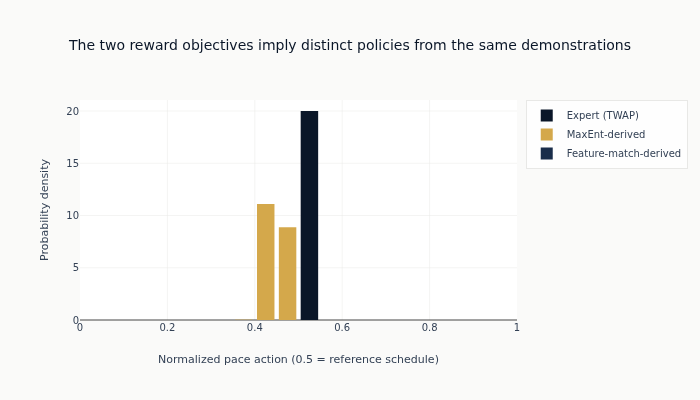

In [37]:
fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=expert_actions,
        name="Expert (TWAP)",
        marker_color=COLORS["blue"],
        xbins=dict(start=bin_edges[0], end=bin_edges[-1], size=bin_edges[1] - bin_edges[0]),
        histnorm="probability density",
    )
)
fig.add_trace(
    go.Histogram(
        x=maxent_actions,
        name="MaxEnt-derived",
        marker_color=COLORS["amber"],
        xbins=dict(start=bin_edges[0], end=bin_edges[-1], size=bin_edges[1] - bin_edges[0]),
        histnorm="probability density",
    )
)
fig.add_trace(
    go.Histogram(
        x=feature_match_actions,
        name="Feature-match-derived",
        marker_color=COLORS["slate"],
        xbins=dict(start=bin_edges[0], end=bin_edges[-1], size=bin_edges[1] - bin_edges[0]),
        histnorm="probability density",
    )
)

fig.update_layout(
    title="The two reward objectives imply distinct policies from the same demonstrations",
    xaxis_title="Normalized pace action (0.5 = reference schedule)",
    yaxis_title="Probability density",
    barmode="group",
    height=400,
)
fig.update_xaxes(range=[0.0, 1.0])

fig.show()

In [38]:
if EXPORT_RESULTS:
    actions_df = pl.DataFrame(
        {
            "policy": ["Expert (TWAP)"] * len(expert_actions)
            + ["MaxEnt-derived"] * len(maxent_actions)
            + ["Feature-match-derived"] * len(feature_match_actions),
            "action": list(expert_actions) + list(maxent_actions) + list(feature_match_actions),
        }
    )
    actions_df.write_parquet(OUTPUT_DIR / "action_distributions.parquet")
    print(f"Action distributions saved to {OUTPUT_DIR / 'action_distributions.parquet'}")

## 6. Summary

In [39]:
maxent_top_feature, maxent_top_weight = maxent_sorted[0]
feature_top_feature, feature_top_weight = feature_match_sorted[0]
summary = pl.DataFrame(
    {
        "Metric": [
            "Expert trajectories",
            "State-action pairs",
            "MaxEnt candidate trajectories",
            "MaxEnt log-likelihood change",
            "Feature-match final mismatch",
            "MaxEnt dominant feature",
            "Feature-match dominant feature",
        ],
        "Value": [
            str(config["n_expert_trajectories"]),
            str(len(expert_data["states"])),
            str(irl_result["candidate_count"]),
            (
                f"{irl_result['history']['log_likelihood'][0]:.4f} to "
                f"{irl_result['history']['log_likelihood'][-1]:.4f}"
            ),
            f"{feature_match_result['history']['gradient_norm'][-1]:.4f}",
            f"{maxent_top_feature} ({maxent_top_weight:+.4f})",
            f"{feature_top_feature} ({feature_top_weight:+.4f})",
        ],
    }
)
summary

Metric,Value
str,str
"""Expert trajectories""","""200"""
"""State-action pairs""","""6000"""
"""MaxEnt candidate trajectories""","""560"""
"""MaxEnt log-likelihood change""","""-6.2966 to -6.1799"""
"""Feature-match final mismatch""","""4.0529"""
"""MaxEnt dominant feature""","""action (-0.0920)"""
"""Feature-match dominant feature""","""action*inventory (+0.4083)"""


## Key Takeaways

### Behavior Cloning vs IRL

| Aspect | Behavior Cloning | Feature Matching | Sampled MaxEnt IRL |
|--------|------------------|------------------|--------------------|
| **Learns** | Policy $\pi(a \mid s)$ | Reward $R(s,a)$ | Reward $R(s,a)$ |
| **Method** | Supervised learning | Rollout moment matching | Trajectory likelihood |
| **Normalization** | None | None | Explicit partition function |
| **Output** | "What to do" | "Why to do it" | "Why to do it" |
| **Main failure mode** | Compounding action error | Cycling and non-identifiability | Support approximation and non-identifiability |


In [40]:
bc_ratio = bc_nn_results["mean_shortfall"] / expert_results["mean_shortfall"]
maxent_ratio = maxent_policy_results["mean_shortfall"] / expert_results["mean_shortfall"]
feature_match_ratio = (
    feature_match_policy_results["mean_shortfall"] / expert_results["mean_shortfall"]
)
display(
    Markdown(
        f"""
### What This Notebook Demonstrates

The neural behavior clone's mean implementation shortfall is {bc_ratio:.2f} times the expert's on
the common evaluation seeds. Small action errors can compound when the learned policy visits states
that differ from its trajectory-level training sample.

Sampled MaxEnt assigns its largest absolute coefficient to **{maxent_top_feature}**
({maxent_top_weight:+.3f}), while feature matching selects **{feature_top_feature}**
({feature_top_weight:+.3f}). The MaxEnt trajectory log likelihood improves from
{irl_result["history"]["log_likelihood"][0]:.3f} to
{irl_result["history"]["log_likelihood"][-1]:.3f}; feature matching ends with a residual moment gap
of {feature_match_result["history"]["gradient_norm"][-1]:.3f}. Different objectives therefore
produce different reward decompositions from identical demonstrations.

The MaxEnt and feature-match diagnostic policies have mean shortfalls of {maxent_ratio:.2f} and
{feature_match_ratio:.2f} times the expert's, respectively. Neither coefficient vector is a
structural estimate: TWAP ignores market depth and volatility, so large weights on correlated
features expose reward non-identifiability rather than hidden trader preferences.
"""
    )
)


### What This Notebook Demonstrates

The neural behavior clone's mean implementation shortfall is 1.00 times the expert's on
the common evaluation seeds. Small action errors can compound when the learned policy visits states
that differ from its trajectory-level training sample.

Sampled MaxEnt assigns its largest absolute coefficient to **action**
(-0.092), while feature matching selects **action*inventory**
(+0.408). The MaxEnt trajectory log likelihood improves from
-6.297 to
-6.180; feature matching ends with a residual moment gap
of 4.053. Different objectives therefore
produce different reward decompositions from identical demonstrations.

The MaxEnt and feature-match diagnostic policies have mean shortfalls of 1.00 and
0.99 times the expert's, respectively. Neither coefficient vector is a
structural estimate: TWAP ignores market depth and volatility, so large weights on correlated
features expose reward non-identifiability rather than hidden trader preferences.
